# 1. A primer on the scipy functions & Methods

The difference between `fsolve` and `solve_ivp` lies in their purposes and approaches to solving mathematical problems:

### 📌 **1. `solve_ivp` (Solves Initial Value Problems for ODEs):**
- **Purpose:** Solves ordinary differential equations (ODEs) given an initial condition and integrates the system over a time interval.
- **Method:** Uses numerical integration (e.g., Runge-Kutta methods) to calculate the values of variables over time.
- **Input:** Requires an initial state and a time range.
- **Output:** Provides the solution (state variables) over the time interval.
- **Usage Example:** Simulating the dynamic behavior of a system (e.g., population growth, chemical reactions).

**In our case:** We used `solve_ivp` to observe how \(x_1\) and \(x_2\) evolve from their initial values (\(x_1 = 1, x_2 = 1\)) over time \([0, 5]\).

---

### 📌 **2. `fsolve` (Solves Nonlinear Equations):**
- **Purpose:** Solves systems of equations to find the roots where the equations equal zero (steady-state solutions).
- **Method:** Uses iterative root-finding algorithms (e.g., Newton-Raphson method).
- **Input:** Requires a system of equations and an initial guess for the solution.
- **Output:** Provides the values of the variables that make the system of equations equal zero.
- **Usage Example:** Finding equilibrium or steady-state solutions where time derivatives vanish (\(\frac{dx}{dt} = 0\)).

**In our case:** We used `fsolve` to find the steady state where \(\frac{dx_1}{dt} = 0\) and \(\frac{dx_2}{dt} = 0\).

---

### ⚖️ **Key Difference:**
- `solve_ivp` shows the *path* of the system over time (dynamic simulation).
- `fsolve` directly finds the *final equilibrium point* without simulating the entire path.

Would you like me to illustrate this further with another example or code? 😊

# 2.🧩 **Stiff vs. Non-Stiff ODE Systems** and Why Different Methods Are Required

#### 📌 **1. What Are Stiff and Non-Stiff Systems?**

1. **Non-Stiff Systems:**  
   - These are ODEs where the solution changes gradually and can be accurately approximated with standard numerical methods.  
   - **Step sizes** (how far the solver moves between points) can be relatively large without losing accuracy or stability.  
   - Example: Simple harmonic oscillators, population growth models, or chemical reactions with similar timescales.

2. **Stiff Systems:**  
   - These are ODEs where the solution has **rapidly changing components (fast dynamics)** and **slowly changing components (slow dynamics)** simultaneously.  
   - The solver requires **extremely small step sizes** to maintain numerical stability, making computations slow if using standard methods.  
   - Example: Chemical kinetics with fast and slow reactions, electrical circuits, or enzyme kinetics.

---

#### 🧮 **2. Why Different Methods Are Required**
Stiff systems are challenging because standard numerical methods (like Euler’s or Runge-Kutta) become inefficient or unstable unless they use very small time steps. Special algorithms are designed to handle stiffness efficiently.

---

#### ⚙️ **3. Numerical Methods and Their Suitability**

| **Method**                  | **Best for**         | **Stiff/Non-Stiff** | **Pros** | **Cons** |
|-----------------------------|----------------------|---------------------|----------|----------|
| **`RK45` (Runge-Kutta 4/5)** | Smooth, predictable systems | Non-stiff         | High accuracy, easy to use | Slow for stiff systems |
| **`Radau` (Implicit Runge-Kutta)** | Stiff systems with smooth solutions | Stiff            | Efficient for stiff ODEs | More complex, slower per step |
| **`BDF` (Backward Differentiation Formula)** | Stiff systems with rapid decay | Stiff            | Very efficient for stiff ODEs | Needs Jacobian for best results |
| **`LSODA` (Automatic method switching)** | Unknown stiffness | Both             | Automatically switches between methods | Slightly more overhead |

---

#### 🚀 **4. Practical Example of Stiff Systems**
Consider a chemical reaction:
\[
A \xrightarrow{k_1} B \quad (\text{Fast reaction})
\]
\[
B \xrightarrow{k_2} C \quad (\text{Slow reaction})
\]

- `solve_ivp` with `RK45` struggles because it uses the same time step for both fast and slow dynamics, causing inefficiency.
- `solve_ivp` with `BDF` or `Radau` handles the stiffness by adjusting step sizes effectively.

---

#### 🧩 **5. Key Insight: Stiffness Isn’t About Speed; It’s About Stability**
A system is stiff if numerical solvers become unstable unless they take very tiny time steps. The system might converge quickly, but the solver struggles with stability.

---

Would you like me to demonstrate the difference between a stiff and non-stiff solver on an example system? 😊

# 3. Differences Between Linear and Nonlinear ODE Systems

1. **Linear Systems**: The derivatives can be expressed as a matrix multiplication `A @ x`, where `x` is the state vector. For example:

   $$
   \frac{d}{dt}\begin{bmatrix} x_1 \\ x_2 \end{bmatrix} = \begin{bmatrix} -1 & -1 \\ 1 & -2 \end{bmatrix}\begin{bmatrix} x_1 \\ x_2 \end{bmatrix}.
   $$

   The system depends linearly on the variables, making it simpler and often easier to solve.

2. **Nonlinear Systems**: The derivatives involve products or more complex functions of the variables (e.g., `[A]*[D]`). For instance:

   $$
   \frac{d[A]}{dt} = -k_1[A] - k_2[A][D],\quad \frac{d[D]}{dt} = k_1[A] - k_2[A][D],\quad \frac{d[U]}{dt} = k_2[A][D].
   $$

   Nonlinear systems can have more complex behavior (multiple steady states, etc.).


# Create Virtual Env and Install the Packages

**Optional**: Only run the following cell if you want to create a virtual environment and install the packages on your local computer.

In [1]:
!python -m venv .venv 
!source .venv/bin/activate
!pip install --upgrade pip
!pip install ipykernel
!pip install numpy scipy matplotlib pandas

^C
Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/jlab-env/lib/python3.12/venv/__main__.py", line 6, in <module>
    main()
  File "/opt/jlab-env/lib/python3.12/venv/__init__.py", line 566, in main
    builder.create(d)
  File "/opt/jlab-env/lib/python3.12/venv/__init__.py", line 76, in create
    self._setup_pip(context)
  File "/opt/jlab-env/lib/python3.12/venv/__init__.py", line 386, in _setup_pip
    self._call_new_python(context, '-m', 'ensurepip', '--upgrade',
  File "/opt/jlab-env/lib/python3.12/venv/__init__.py", line 382, in _call_new_python
    subprocess.check_output(args, **kwargs)
  File "/opt/jlab-env/lib/python3.12/subprocess.py", line 466, in check_output
    return run(*popenargs, stdout=PIPE, timeout=timeout, check=True,
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/jlab-env/lib/python3.12/subprocess.py", line 550, in run
    st

# Setup

In [2]:
# Import the right packages
import os
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve
import matplotlib.pyplot as plt
import time

In [4]:
# Create folders to save figures
results_dir_parent_path = os.path.join(os.getcwd(), 'results')
results_dir_exercise_1_path = os.path.join(results_dir_parent_path, 'exercise_1')
results_dir_exercise_2_path = os.path.join(results_dir_parent_path, 'exercise_2')
results_dir_exercise_3_path = os.path.join(results_dir_parent_path, 'exercise_3')
results_dir_paths = [
    results_dir_parent_path,
    results_dir_exercise_1_path,
    results_dir_exercise_2_path,
    results_dir_exercise_3_path
]

for result_dir_path in results_dir_paths:
    os.makedirs(result_dir_path, exist_ok=True)


In [5]:
# Constants
NB_POINTS = 100 # number of time points we typically want: 100 is usually a good starting point, as 1000 points may be too time-consuming

# Exercise 1 (Linear ODEs)

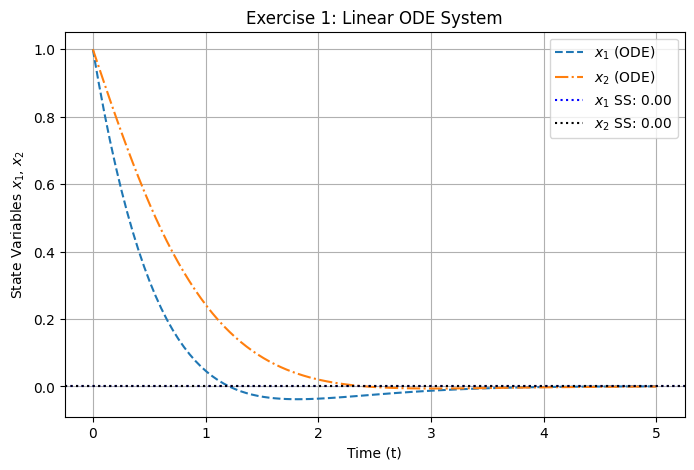

In [6]:
def linear_odes(t, x):
    """Defines our linear ODE system dx/dt = A x."""
    A = np.array([[-1, -1],
                  [ 1, -2]])
    return A @ x  # Matrix multiplication

# 1) Initial conditions
initial_conditions = [1, 1]  # x1(0) = 1, x2(0) = 1

# 2) Time range for solution
time_span = [0, 5]  # from t=0 to t=5

# 3) Solve using solve_ivp
#    method='RK45' is good for non-stiff problems.
#    t_eval=np.linspace(...) means we want the solver to report 100 points between 0 and 5.
solution = solve_ivp(
    fun=linear_odes,
    t_span=time_span,
    y0=initial_conditions,
    method='RK45',
    t_eval=np.linspace(0, 5, NB_POINTS)
)

# 4) Steady-state with fsolve
#    A steady state occurs when dx/dt=0 => A x = 0.
#    We'll guess [1,1] to start.

def steady_state_equations(x):
    return linear_odes(0, x)

steady_state_solution = fsolve(steady_state_equations, [1, 1])

# 5) Plot results
plt.figure(figsize=(8, 5))
plt.plot(solution.t, solution.y[0], label='$x_1$ (ODE)', linestyle='--')
plt.plot(solution.t, solution.y[1], label='$x_2$ (ODE)', linestyle='-.')
plt.axhline(steady_state_solution[0], color='blue', linestyle=':',
            label=f'$x_1$ SS: {steady_state_solution[0]:.2f}')
plt.axhline(steady_state_solution[1], color='black', linestyle=':',
            label=f'$x_2$ SS: {steady_state_solution[1]:.2f}')
plt.xlabel('Time (t)')
plt.ylabel('State Variables $x_1$, $x_2$')
plt.title('Exercise 1: Linear ODE System')
plt.legend()
plt.grid(True)
# Save figure
plt.savefig(os.path.join(results_dir_exercise_1_path, 'exercise_1_solution.png'))
plt.show()

# 6) Prepare results for display
results_e1 = pd.DataFrame({
    'Time': solution.t,
    'x1 (ODE)': solution.y[0],
    'x2 (ODE)': solution.y[1]
})

steady_state_df_e1 = pd.DataFrame({
    'Variable': ['x1', 'x2'],
    'Steady State (fsolve)': steady_state_solution,
    'Final Value (ODE)': [solution.y[0][-1], solution.y[1][-1]]
})

In [7]:
# 7.1) Manual inspection of the results is often helpful, especially when facing more complex problem
results_e1

,Time,x1 (ODE),x2 (ODE)
0,0.000000,1.000000,1.000000
1,0.050505,0.902752,0.949557
2,0.101010,0.812775,0.899476
3,0.151515,0.729757,0.850157
4,0.202020,0.653283,0.801809
...,...,...,...
95,4.797980,-0.000027,-0.000760
96,4.848485,0.000010,-0.000687
97,4.898990,0.000042,-0.000620
98,4.949495,0.000068,-0.000558


In [8]:
steady_state_df_e1

,Variable,Steady State (fsolve),Final Value (ODE)
0,x1,0.0,0.000091
1,x2,0.0,-0.000500


In [ ]:
# 8) We close all the plots created with matplotlib to free some memory and ensure good code performance
plt.close('all') # especially relevant if you use python script instead of notebooks

# Exercise 2 (Linear, Stiff vs Nonstiff)

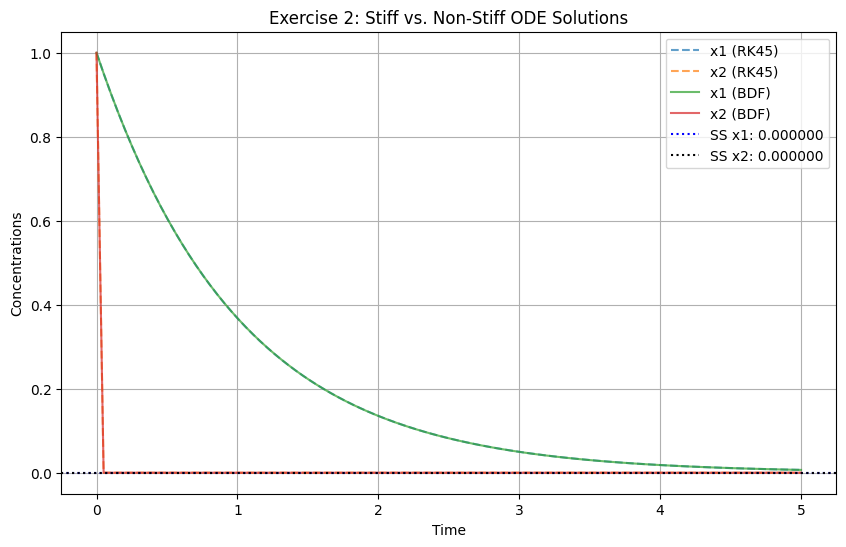

In [11]:
# 1) We now define another linear system but with large coefficients => stiff.
def stiff_odes(t, x):
    """Stiff ODE system."""
    A = np.array([[-1, -1],
                  [ 1, -1e6]])  # Very large term => stiffness
    return A @ x

initial_conditions_e2 = [1, 1]
time_span_e2 = [0, 5]
t_eval_e2 = np.linspace(0, 5, NB_POINTS)

# 2) Solve using Non-Stiff Method (RK45)
start_ns = time.time()
sol_ns = solve_ivp(
    fun=stiff_odes,
    t_span=time_span_e2,
    y0=initial_conditions_e2,
    method='RK45',
    t_eval=t_eval_e2
)
end_ns = time.time()
rk45_time = end_ns - start_ns

# 3) Solve using Stiff Method (BDF)
start_stiff = time.time()
sol_stiff = solve_ivp(
    fun=stiff_odes,
    t_span=time_span_e2,
    y0=initial_conditions_e2,
    method='BDF',
    t_eval=t_eval_e2
)
end_stiff = time.time()
bdf_time = end_stiff - start_stiff

# 4) Steady-State with fsolve
# Stiff or not, the steady state is A x = 0.

def stiff_steady_state(x):
    return stiff_odes(0, x)

steady_state_sol_e2 = fsolve(stiff_steady_state, [1, 1])

# 5) Compare Results
results_e2 = pd.DataFrame({
    'Time': sol_ns.t,
    'x1 (Non-Stiff)': sol_ns.y[0],
    'x2 (Non-Stiff)': sol_ns.y[1]
})

# 6) We might have different t arrays for sol_stiff vs sol_ns.
# For a fair comparison, we can just plot both.

# Plot
plt.figure(figsize=(10, 6))
plt.plot(sol_ns.t, sol_ns.y[0], label='x1 (RK45)', linestyle='--', alpha=0.7)
plt.plot(sol_ns.t, sol_ns.y[1], label='x2 (RK45)', linestyle='--', alpha=0.7)
plt.plot(sol_stiff.t, sol_stiff.y[0], label='x1 (BDF)', linestyle='-', alpha=0.7)
plt.plot(sol_stiff.t, sol_stiff.y[1], label='x2 (BDF)', linestyle='-', alpha=0.7)

plt.axhline(steady_state_sol_e2[0], color='blue', linestyle=':',
            label=f'SS x1: {steady_state_sol_e2[0]:.6f}')
plt.axhline(steady_state_sol_e2[1], color='black', linestyle=':',
            label=f'SS x2: {steady_state_sol_e2[1]:.6f}')

plt.xlabel('Time')
plt.ylabel('Concentrations')
plt.title('Exercise 2: Stiff vs. Non-Stiff ODE Solutions')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(results_dir_exercise_2_path, 'exercise_2_solution.png'))
plt.show()

# Efficiency comparison
efficiency_df_e2 = pd.DataFrame({
    'Method': ['RK45 (Non-Stiff)', 'BDF (Stiff)'],
    'Time (s)': [rk45_time, bdf_time]
})


In [12]:
efficiency_df_e2

,Method,Time (s)
0,RK45 (Non-Stiff),184.570101
1,BDF (Stiff),0.017107


In [ ]:
plt.close('all') # especially relevant if you use python script instead of notebooks

# Exercise 3 (Nonlinear)

### **Problem Setup:**

#### **Reactions:**
1. $A \xrightarrow{k_1} D$  
2. $A + D \xrightarrow{k_2} U$  

#### **Mass Balance Equations:**  
From the law of mass action:

- **Rate of Reaction 1:** $R_1 = k_1 [A]$  
- **Rate of Reaction 2:** $R_2 = k_2 [A][D]$  

**Mass Balances:**
$$
\frac{d[A]}{dt} = -R_1 - R_2 = -k_1[A] - k_2[A][D]
$$
$$
\frac{d[D]}{dt} = R_1 - R_2 = k_1[A] - k_2[A][D]
$$
$$
\frac{d[U]}{dt} = R_2 = k_2[A][D]
$$

---

### **Given Parameters:**

- **Rate constants:**  
  - $k_1 = 2 \, \text{h}^{-1}$  
  - $k_2 = 1 \, \text{L} \times \text{mol}^{-1} \times \text{h}^{-1}$  

- **Initial Conditions:**  
  - $[A]_0 = 2 \, \text{mol} \times \text{L}^{-1}$  
  - $[D]_0 = 0 \, \text{mol} \times \text{L}^{-1}$  
  - $[U]_0 = 0 \, \text{mol} \times \text{L}^{-1}$  

- **Time interval:**  
  - $t = [0, 3] \, \text{h}$  


In [ ]:
# 1) ODE Definition: Nonlinear Reaction System
def reaction_odes(t, y, k1, k2):
    """
    Defines the system of ODEs for the reactions:
    
    Reactions:
    1) A -> D (rate: k1[A])
    2) A + D -> U (rate: k2[A][D])

    Differential Equations (Law of Mass Action):
    -------------------------------------------
    d[A]/dt = -k1*A - k2*A*D    # A is consumed in both reactions
    d[D]/dt =  k1*A - k2*A*D    # D is produced in reaction 1 and consumed in reaction 2
    d[U]/dt =         k2*A*D    # U is produced only in reaction 2

    Arguments:
    ----------
    t : float
        Time (independent variable).
    y : list or array
        Current concentrations [A, D, U].
    k1 : float
        Rate constant for A -> D.
    k2 : float
        Rate constant for A + D -> U.

    Returns:
    --------
    list of float
        Time derivatives [dA/dt, dD/dt, dU/dt].
    """
    A, D, U = y
    dA_dt = -k1 * A - k2 * A * D
    dD_dt =  k1 * A - k2 * A * D
    dU_dt =  k2 * A * D
    return [dA_dt, dD_dt, dU_dt]

# 2) Given Parameters
k1_val = 2  # h^-1
k2_val = 1  # L·mol^-1·h^-1

initial_conditions_e3 = [2.0, 0.0, 0.0]  # [A0, D0, U0]
time_span_e3 = [0, 3]                   # From t=0 to t=3 hours
t_eval_e3 = np.linspace(0, 3, NB_POINTS)

# 🚨 Explanation of 'args' in solve_ivp:
# -------------------------------------
# The 'args' parameter allows us to pass additional arguments to the ODE function
# without manually using a lambda or defining a partial function.
# Here, (k1_val, k2_val) are passed directly to `reaction_odes`.
#
# Without `args`, calling `reaction_odes()` would fail because it expects three arguments: (t, y, k1, k2).
# 
# Usage: 
# solve_ivp(fun, t_span, y0, method, t_eval, args=(k1, k2))
#
# `solve_ivp` will call `reaction_odes(t, y, k1_val, k2_val)` internally.
#

# 3) Solve ODE System with RK45 Method
sol_e3 = solve_ivp(
    fun=reaction_odes,                # ODE function
    t_span=time_span_e3,              # Time span
    y0=initial_conditions_e3,         # Initial concentrations [A, D, U]
    method='RK45',                    # Explicit Runge-Kutta (suitable for non-stiff problems)
    t_eval=t_eval_e3,                 # Time points to store results
    args=(k1_val, k2_val)             # Additional arguments for reaction_odes (passed via 'args')
)

# 4) Steady-State with fsolve
# -----------------------------
# At steady state, dA/dt = dD/dt = dU/dt = 0.
# So, reaction_odes(0, [A, D, U], k1, k2) = [0, 0, 0].

def reaction_steady_state(y):
    """Returns the residual of the reaction ODEs at steady state."""
    return reaction_odes(0, y, k1_val, k2_val)

# 🚨 Best Practice for Choosing Initial Values for fsolve:
# -------------------------------------------------------
# fsolve uses an iterative method (typically Newton-Raphson) to find roots.
# The initial guess can strongly influence convergence.

# 1️⃣ **Why Not [0, 0, 0]?**
# - Using [0, 0, 0] is risky because:
#    - It may cause the solver to stall in a trivial solution.
#    - Near-zero values may cause numerical instability or division-by-zero issues (if applicable).
#
# 2️⃣ **Why Use [1e-5, 1e-5, 1e-5]?**
# - Small non-zero values help the solver avoid flat or singular regions of the solution space.
# - A non-zero guess can help the solver differentiate directions for finding a solution.

# 3️⃣ **Other Good Practices:**
# - Use the ODE’s final value as a guess (e.g., sol_e3.y[:, -1]).
# - Analyze the reaction stoichiometry or approximate expected concentrations.

# Using a small non-zero guess:
steady_state_sol_e3 = fsolve(reaction_steady_state, [1e-5, 1e-5, 1e-5])

print(f"Steady-state solution: [A, D, U] = {steady_state_sol_e3}")

# 5) Plot Nonlinear ODE Results
plt.figure(figsize=(10, 6))
plt.plot(sol_e3.t, sol_e3.y[0], label='[A]', linestyle='-', alpha=0.8, color='blue')
plt.plot(sol_e3.t, sol_e3.y[1], label='[D]', linestyle='--', alpha=0.8, color='green')
plt.plot(sol_e3.t, sol_e3.y[2], label='[U]', linestyle='-.', alpha=0.8, color='red')

# Add steady-state lines
plt.axhline(steady_state_sol_e3[0], color='blue', linestyle=':',
            label=f'SS [A]: {steady_state_sol_e3[0]:.6f}')
plt.axhline(steady_state_sol_e3[1], color='green', linestyle=':',
            label=f'SS [D]: {steady_state_sol_e3[1]:.6f}')
plt.axhline(steady_state_sol_e3[2], color='red', linestyle=':',
            label=f'SS [U]: {steady_state_sol_e3[2]:.6f}')

plt.xlabel('Time (hours)')
plt.ylabel('Concentration (mol/L)')
plt.title('Exercise 3: Nonlinear ODE - A, D, U Reactions')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(results_dir_exercise_3_path, 'exercise_3_solution.png'))
plt.show()

# 6) Store Results in a DataFrame
results_e3 = pd.DataFrame({
    'Time (h)': sol_e3.t,
    'A (mol/L)': sol_e3.y[0],
    'D (mol/L)': sol_e3.y[1],
    'U (mol/L)': sol_e3.y[2]
})


In [ ]:
results_e3

In [ ]:
plt.close('all') # especially relevant if you use python script instead of notebooks